# 📖 Notebook 03: Transformer ブロック全体
## — Attention の前後に何が付くか —

### Transformer ブロックの構造

```
             X（入力）
             │
    ┌────────┤
    │        ↓
    │   MultiHeadAttention(X)
    │        │
    └───→ Add（残差接続）
             │
          LayerNorm
             │ X'
    ┌────────┤
    │        ↓
    │   FeedForward(X')
    │        │
    └───→ Add（残差接続）
             │
          LayerNorm
             │
          出力（X と同じ shape）
```

このブロックを $N$ 回積み重ねたものが Transformer モデルです。

### このノートで学ぶこと
1. **Layer Normalization** — なぜ Batch Norm でなく Layer Norm か
2. **残差接続（Residual Connection）** — 深いネットワークを安定学習させる仕組み
3. **Feed-Forward Network** — 各トークンへの非線形変換
4. **N 層スタック** — ブロックを重ねると何が起きるか
5. **LM Head** — 語彙スコアへの変換

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})

# 全コンポーネントを再定義
vocab_size = 8
d_model    = 4
seq_len    = 4
num_heads  = 2
d_k_head   = d_model // num_heads
d_ff       = 8
tokens     = [2, 5, 1, 3]

def softmax(x, axis=-1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

def positional_encoding(seq_len, d_model):
    PE = np.zeros((seq_len, d_model))
    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            angle = pos / (10000 ** (2 * i / d_model))
            PE[pos, i]   = np.sin(angle)
            if i + 1 < d_model:
                PE[pos, i+1] = np.cos(angle)
    return PE

def sdpa(Q, K, V):
    seq_len, d_k = Q.shape
    scores = Q @ K.T / np.sqrt(d_k)
    mask = np.triu(np.ones((seq_len, seq_len), dtype=bool), k=1)
    scores[mask] = -1e9
    return softmax(scores, axis=-1) @ V

np.random.seed(42)
E = np.random.randn(vocab_size, d_model)
X = E[tokens] + positional_encoding(seq_len, d_model)

np.random.seed(1)
W_Qs = [np.random.randn(d_model, d_k_head) * 0.5 for _ in range(num_heads)]
W_Ks = [np.random.randn(d_model, d_k_head) * 0.5 for _ in range(num_heads)]
W_Vs = [np.random.randn(d_model, d_k_head) * 0.5 for _ in range(num_heads)]
W_O  = np.random.randn(d_model, d_model) * 0.5

heads = [sdpa(X @ W_Qs[h], X @ W_Ks[h], X @ W_Vs[h]) for h in range(num_heads)]
mha_output = np.concatenate(heads, axis=-1) @ W_O

print(f"X (入力):         shape = {X.shape}")
print(f"mha_output (MHA): shape = {mha_output.shape}")

X (入力):         shape = (4, 4)
mha_output (MHA): shape = (4, 4)


---
## 1. Layer Normalization

### なぜ正規化が必要か

層が深くなるにつれて各層の入力の分布が変化（**内部共変量シフト**）し、
学習が不安定になります。正規化によってこれを防ぎます。

### Batch Norm vs Layer Norm

| | Batch Norm | **Layer Norm** |
|--|------------|----------------|
| 正規化方向 | バッチ次元 | **特徴次元** |
| バッチサイズへの依存 | あり | **なし** |
| 系列モデルへの適合 | 困難 | **良好** |

Transformer では **1 トークンずつ**、その特徴次元方向で正規化します。

$$\text{LayerNorm}(x) = \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \varepsilon}} + \beta$$

- $\mu, \sigma^2$：トークン $x$ の特徴次元での平均・分散
- $\gamma, \beta$：学習パラメータ（初期値 1, 0）
- $\varepsilon = 10^{-6}$：ゼロ除算防止

In [2]:
def layer_norm(x, gamma, beta, eps=1e-6):
    mean = x.mean(axis=-1, keepdims=True)
    var  = x.var(axis=-1, keepdims=True)
    return gamma * (x - mean) / np.sqrt(var + eps) + beta

gamma = np.ones(d_model)
beta  = np.zeros(d_model)

# 手計算確認: mha_output[0] の LayerNorm
row  = mha_output[0]
mu   = row.mean()
var  = row.var()
hat  = (row - mu) / np.sqrt(var + 1e-6)

print("━━━ 手計算確認: LayerNorm(mha_output[0]) ━━━")
print(f"入力 x        = {row}")
print(f"平均 μ        = ({' + '.join([f'{v:.4f}' for v in row])}) / {d_model} = {mu:.4f}")
print(f"分散 σ²       = mean((x-μ)²) = {var:.4f}")
print(f"(x-μ)/√(σ²+ε) = {hat}")
print(f"γ*(x-μ)/σ + β = {gamma * hat + beta}")
print()

ln_out = layer_norm(mha_output, gamma, beta)
print(f"LayerNorm(mha_output): shape = {ln_out.shape}")
print(ln_out)
print()
print("各行の平均（≈ 0）:", ln_out.mean(axis=-1).round(8))
print("各行の分散（≈ 1）:", ln_out.var(axis=-1).round(6))

━━━ 手計算確認: LayerNorm(mha_output[0]) ━━━
入力 x        = [-1.2139  1.2118  0.5169 -0.5124]
平均 μ        = (-1.2139 + 1.2118 + 0.5169 + -0.5124) / 4 = 0.0006
分散 σ²       = mean((x-μ)²) = 0.8679
(x-μ)/√(σ²+ε) = [-1.3036  1.3001  0.5542 -0.5506]
γ*(x-μ)/σ + β = [-1.3036  1.3001  0.5542 -0.5506]

LayerNorm(mha_output): shape = (4, 4)
[[-1.3036  1.3001  0.5542 -0.5506]
 [ 0.776  -0.4489  1.0899 -1.4169]
 [ 1.3617 -0.377   0.3789 -1.3636]
 [ 0.3455 -0.6811 -1.1284  1.464 ]]

各行の平均（≈ 0）: [ 0.  0. -0. -0.]
各行の分散（≈ 1）: [1.     0.9998 0.9999 1.    ]


/tmp/ipykernel_2551/1090162936.py:19: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/1090162936.py:19: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/1090162936.py:19: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/1090162936.py:19: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/1090162936.py:19: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/1090162936.py:19: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/1090162936.py:19: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas

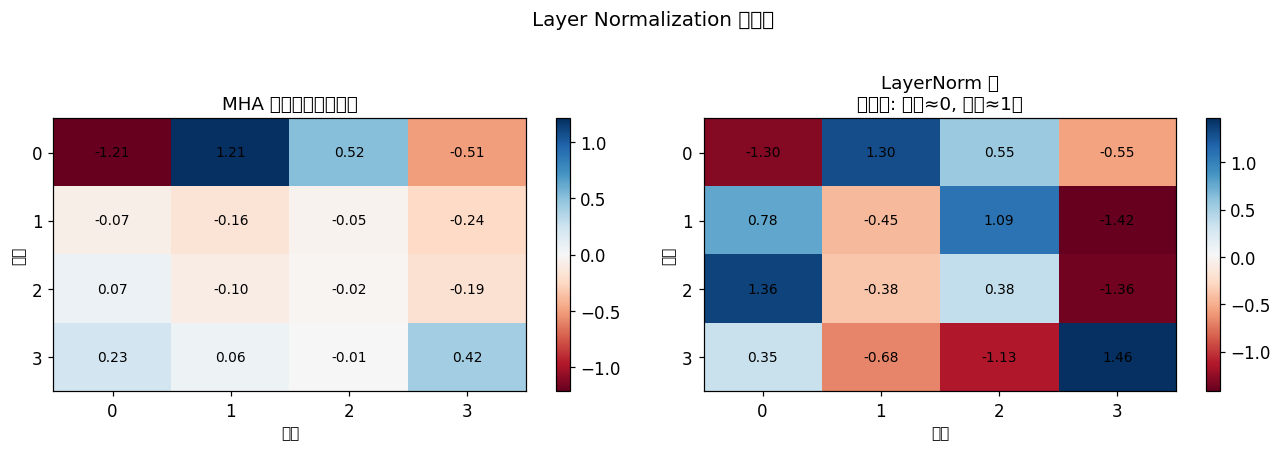

In [3]:
# LayerNorm の効果を可視化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, mat, title in zip(axes,
    [mha_output, ln_out],
    ['MHA 出力（正規化前）', 'LayerNorm 後\n（各行: 平均≈0, 分散≈1）']):
    im = ax.imshow(mat, cmap='RdBu', aspect='auto')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('次元', fontsize=10)
    ax.set_ylabel('位置', fontsize=10)
    ax.set_xticks(range(d_model))
    ax.set_yticks(range(seq_len))
    for i in range(seq_len):
        for j in range(d_model):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax)

plt.suptitle('Layer Normalization の効果', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('docs/nb03_layernorm.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 2. 残差接続（Residual Connection）

$$X' = \text{LayerNorm}(X + \text{MHA}(X))$$

### なぜ残差接続が重要か

**問題**：層を深くすると「勾配消失」が起き、前の層のパラメータが更新されなくなります。

**解決策（ResNet 2015 の発明）**：入力をそのまま足す「ショートカット」を作る。

```
通常:      x → f(x)
残差:      x → f(x) + x
```

- 勾配が直接前の層に届く → 深い層まで学習可能
- `f(x) = 0` にすれば恒等写像になる → 「何もしない」も学習できる
- 学習初期は重みが小さく `f(x) ≈ 0` のため、スキップ経路が主に使われる

In [4]:
# 第1サブレイヤ: MHA + Add & Norm
X_residual = X + mha_output   # 残差接続（入力をそのまま足す）
X_prime    = layer_norm(X_residual, gamma, beta)

print("X（入力）:")
print(X)
print()
print("mha_output（MHA の変換量）:")
print(mha_output)
print()
print("X + mha_output（残差接続）:")
print(X_residual)
print()
print("X' = LayerNorm(X + mha_output):")
print(X_prime)

X（入力）:
[[-0.4695  1.5426 -0.4634  0.5343]
 [ 2.3071  0.3145  0.0676 -0.4247]
 [ 0.6751 -0.6503  1.5794  1.7674]
 [ 0.3831 -2.9033 -1.7246  0.4377]]

mha_output（MHA の変換量）:
[[-1.2139  1.2118  0.5169 -0.5124]
 [-0.0696 -0.1639 -0.0454 -0.2385]
 [ 0.0691 -0.0957 -0.024  -0.1892]
 [ 0.235   0.0649 -0.0092  0.4202]]

X + mha_output（残差接続）:
[[-1.6833  2.7543  0.0535  0.0219]
 [ 2.2376  0.1506  0.0223 -0.6633]
 [ 0.7442 -0.746   1.5554  1.5783]
 [ 0.6181 -2.8383 -1.7338  0.858 ]]

X' = LayerNorm(X + mha_output):
[[-1.24    1.5534 -0.1467 -0.1666]
 [ 1.6601 -0.2638 -0.3821 -1.0141]
 [-0.041  -1.6188  0.8178  0.842 ]
 [ 0.8901 -1.3199 -0.6137  1.0435]]


/tmp/ipykernel_2551/1401209919.py:20: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/1401209919.py:20: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/1401209919.py:20: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/1401209919.py:20: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/1401209919.py:20: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/1401209919.py:20: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/1401209919.py:20: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}

/tmp/ipykernel_2551/1401209919.py:20: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/1401209919.py:20: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/1401209919.py:20: UserWarning: Glyph 32068 (\N{CJK UNIFIED IDEOGRAPH-7D44}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/1401209919.py:20: UserWarning: Glyph 12415 (\N{HIRAGANA LETTER MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/1401209919.py:20: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/1401209919.py:20: UserWarning: Glyph 12431 (\N{HIRAGANA LETTER WA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/1401209919.py:20: UserWarning: Glyph 12379 (\N{HIRAGANA LETTER SE}) missing from font(s) DejaVu Sans.
  pl

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27531 (\N{CJK UNIFIED IDEOGRAPH-6B8B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25509 (\N{CJK UNIFIED IDEOGRAPH-63A5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32154 (\N{CJK UNIFIED IDEOGRAPH-7D9A}) missing from font(s) DejaVu Sans.
  fig.canvas

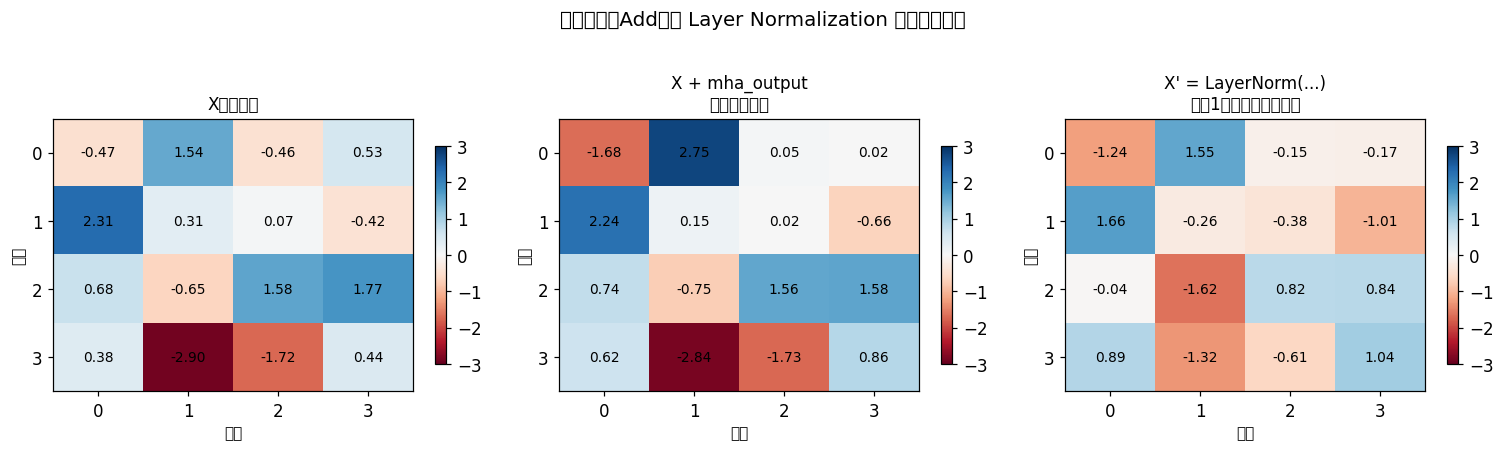

In [5]:
# 残差接続の効果を可視化
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = ['X（入力）', 'X + mha_output\n（残差接続）', 'X\' = LayerNorm(...)\n（第1サブレイヤ出力）']
mats   = [X, X_residual, X_prime]
vrange = 3

for ax, mat, title in zip(axes, mats, titles):
    im = ax.imshow(mat, cmap='RdBu', aspect='auto', vmin=-vrange, vmax=vrange)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('次元', fontsize=10)
    ax.set_ylabel('位置', fontsize=10)
    ax.set_xticks(range(d_model))
    ax.set_yticks(range(seq_len))
    for i in range(seq_len):
        for j in range(d_model):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('残差接続（Add）と Layer Normalization の組み合わせ', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('docs/nb03_residual.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3. Feed-Forward Network（FFN）

Attention が「どこを見るか」を決めるのに対し、
FFN は「何を計算するか（特徴変換）」を担当します。

各トークンに**独立に同じ** MLP を適用します：

$$\text{FFN}(x) = \text{GELU}(x W_1 + b_1) W_2 + b_2$$

- $W_1 \in \mathbb{R}^{d_{\text{model}} \times d_{ff}}$：次元を拡大（通常 4 倍）  
  → ここでは $4 \to 8$（実際の GPT は $768 \to 3072$）
- $W_2 \in \mathbb{R}^{d_{ff} \times d_{\text{model}}}$：元の次元に戻す

### GELU 活性化関数

$$\text{GELU}(x) = x \cdot \Phi(x) \approx 0.5x\left(1 + \tanh\!\left(\sqrt{\tfrac{2}{\pi}}(x + 0.044715x^3)\right)\right)$$

- $\Phi(x)$：標準正規分布の累積分布関数
- ReLU（$\max(0,x)$）の滑らかな近似版
- 負の領域でも微小な勾配を持つ（「死んだニューロン」問題を軽減）

In [6]:
def gelu(x):
    return 0.5 * x * (1.0 + np.tanh(np.sqrt(2.0/np.pi) * (x + 0.044715*x**3)))

np.random.seed(2)
W1 = np.random.randn(d_model, d_ff) * 0.3
b1 = np.zeros(d_ff)
W2 = np.random.randn(d_ff, d_model) * 0.3
b2 = np.zeros(d_model)

print(f"W1: shape = {W1.shape}  （{d_model} → {d_ff}、次元拡大）")
print(f"W2: shape = {W2.shape}  （{d_ff} → {d_model}、次元圧縮）")

W1: shape = (4, 8)  （4 → 8、次元拡大）
W2: shape = (8, 4)  （8 → 4、次元圧縮）


/tmp/ipykernel_2551/51330070.py:32: UserWarning: Glyph 12399 (\N{HIRAGANA LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/51330070.py:32: UserWarning: Glyph 12391 (\N{HIRAGANA LETTER DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/51330070.py:32: UserWarning: Glyph 24494 (\N{CJK UNIFIED IDEOGRAPH-5FAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/51330070.py:32: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/51330070.py:32: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/51330070.py:32: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/51330070.py:32: UserWarning: Glyph 12364 (\N{HIRAGANA LETTER GA}) missing from font(s) DejaVu Sans.
  plt.tigh

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12399 (\N{HIRAGANA LETTER HA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12391 (\N{HIRAGANA LETTER DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24494 (\N{CJK UNIFIED IDEOGRAPH-5FAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, 

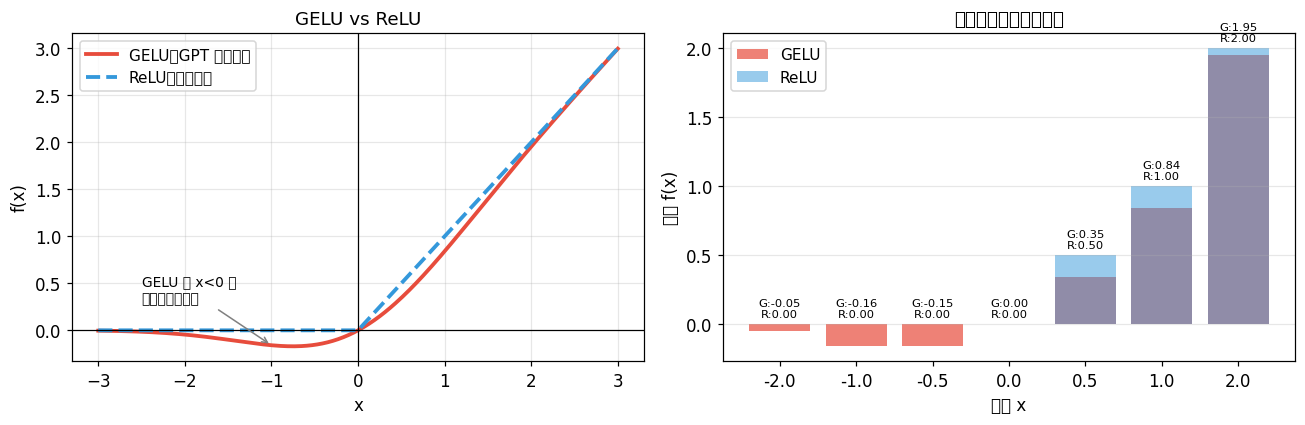

In [7]:
# GELU vs ReLU の比較
x_vals = np.linspace(-3, 3, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_vals, gelu(x_vals),        color='#e74c3c', lw=2.5, label='GELU（GPT で使用）')
axes[0].plot(x_vals, np.maximum(0,x_vals), color='#3498db', lw=2.5, label='ReLU（古典的）', linestyle='--')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('GELU vs ReLU', fontsize=12)
axes[0].set_xlabel('x', fontsize=11)
axes[0].set_ylabel('f(x)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].annotate('GELU は x<0 で\n微小な値が通る', xy=(-1, gelu(-1)), xytext=(-2.5, 0.3),
                  arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)

# サンプル値
sample_x = np.array([-2, -1, -0.5, 0, 0.5, 1, 2])
axes[1].bar(range(len(sample_x)), gelu(sample_x), color='#e74c3c', alpha=0.7, label='GELU')
axes[1].bar(range(len(sample_x)), np.maximum(0, sample_x), color='#3498db', alpha=0.5, label='ReLU')
axes[1].set_xticks(range(len(sample_x)))
axes[1].set_xticklabels([str(v) for v in sample_x])
axes[1].set_title('各入力値での出力比較', fontsize=12)
axes[1].set_xlabel('入力 x', fontsize=11)
axes[1].set_ylabel('出力 f(x)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')
for i, (g, r) in enumerate(zip(gelu(sample_x), np.maximum(0, sample_x))):
    axes[1].text(i, max(g, r) + 0.05, f'G:{g:.2f}\nR:{r:.2f}', ha='center', fontsize=7.5)

plt.tight_layout()
plt.savefig('docs/nb03_gelu.png', dpi=120, bbox_inches='tight')
plt.show()

In [8]:
# FFN の手計算確認（トークン0）
print("━━━ 手計算確認: FFN(X'[0]) ━━━")
x0  = X_prime[0]
h0  = gelu(x0 @ W1 + b1)   # 中間層 (d_ff,)
out0 = h0 @ W2 + b2          # 出力 (d_model,)

print(f"入力 X'[0]  = {x0}")
print()
print(f"X'[0] @ W1  → shape {(x0 @ W1).shape}")
print(f"+ b1        = {x0 @ W1 + b1}")
print()
print(f"GELU(...)   = {h0}")
print(f"  ← 中間層の活性化（{d_ff} 次元に拡大）")
print()
print(f"@ W2 + b2   = {out0}")
print(f"  ← 元の {d_model} 次元に戻す")

ffn_output = gelu(X_prime @ W1 + b1) @ W2 + b2
print()
print(f"全体の FFN 出力: shape = {ffn_output.shape}")
print(ffn_output)
print(f"手計算との差: {np.abs(out0 - ffn_output[0]).max():.2e}  ✓")

━━━ 手計算確認: FFN(X'[0]) ━━━
入力 X'[0]  = [-1.24    1.5534 -0.1467 -0.1666]

X'[0] @ W1  → shape (8,)
+ b1        = [-0.3202 -0.4426  1.1165  0.517   0.7962 -0.1933  0.0663  0.1174]

GELU(...)   = [-0.1199 -0.1456  0.9688  0.3605  0.6266 -0.0818  0.0349  0.0642]
  ← 中間層の活性化（8 次元に拡大）

@ W2 + b2   = [-0.0281  0.2417 -0.3112  0.3195]
  ← 元の 4 次元に戻す

全体の FFN 出力: shape = (4, 4)
[[-0.0281  0.2417 -0.3112  0.3195]
 [ 0.4222 -0.0926  0.2062 -0.208 ]
 [-0.1993 -0.1905  0.0845  0.3596]
 [-0.1724 -0.0699  0.0276  0.1361]]
手計算との差: 1.39e-17  ✓


In [9]:
# 第2サブレイヤ: FFN + Add & Norm
gamma2, beta2 = np.ones(d_model), np.zeros(d_model)
X_out = layer_norm(X_prime + ffn_output, gamma2, beta2)

print("Transformer ブロック出力 X_out = LayerNorm(X' + FFN(X'))")
print(f"shape = {X_out.shape}  ← 入力 X と同じ shape")
print(X_out)

Transformer ブロック出力 X_out = LayerNorm(X' + FFN(X'))
shape = (4, 4)  ← 入力 X と同じ shape
[[-1.1778  1.548  -0.4569  0.0867]
 [ 1.6387 -0.3591 -0.2112 -1.0683]
 [-0.2148 -1.5422  0.7519  1.0051]
 [ 0.7213 -1.3403 -0.5541  1.1731]]


/tmp/ipykernel_2551/3950751115.py:28: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/3950751115.py:28: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/3950751115.py:28: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/3950751115.py:28: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/3950751115.py:28: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/3950751115.py:28: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/3950751115.py:28: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}

/tmp/ipykernel_2551/3950751115.py:29: UserWarning: Glyph 20869 (\N{CJK UNIFIED IDEOGRAPH-5185}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb03_block_flow.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_2551/3950751115.py:29: UserWarning: Glyph 22793 (\N{CJK UNIFIED IDEOGRAPH-5909}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb03_block_flow.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_2551/3950751115.py:29: UserWarning: Glyph 25563 (\N{CJK UNIFIED IDEOGRAPH-63DB}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb03_block_flow.png', dpi=120, bbox_inches='tight')


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  fig.canvas

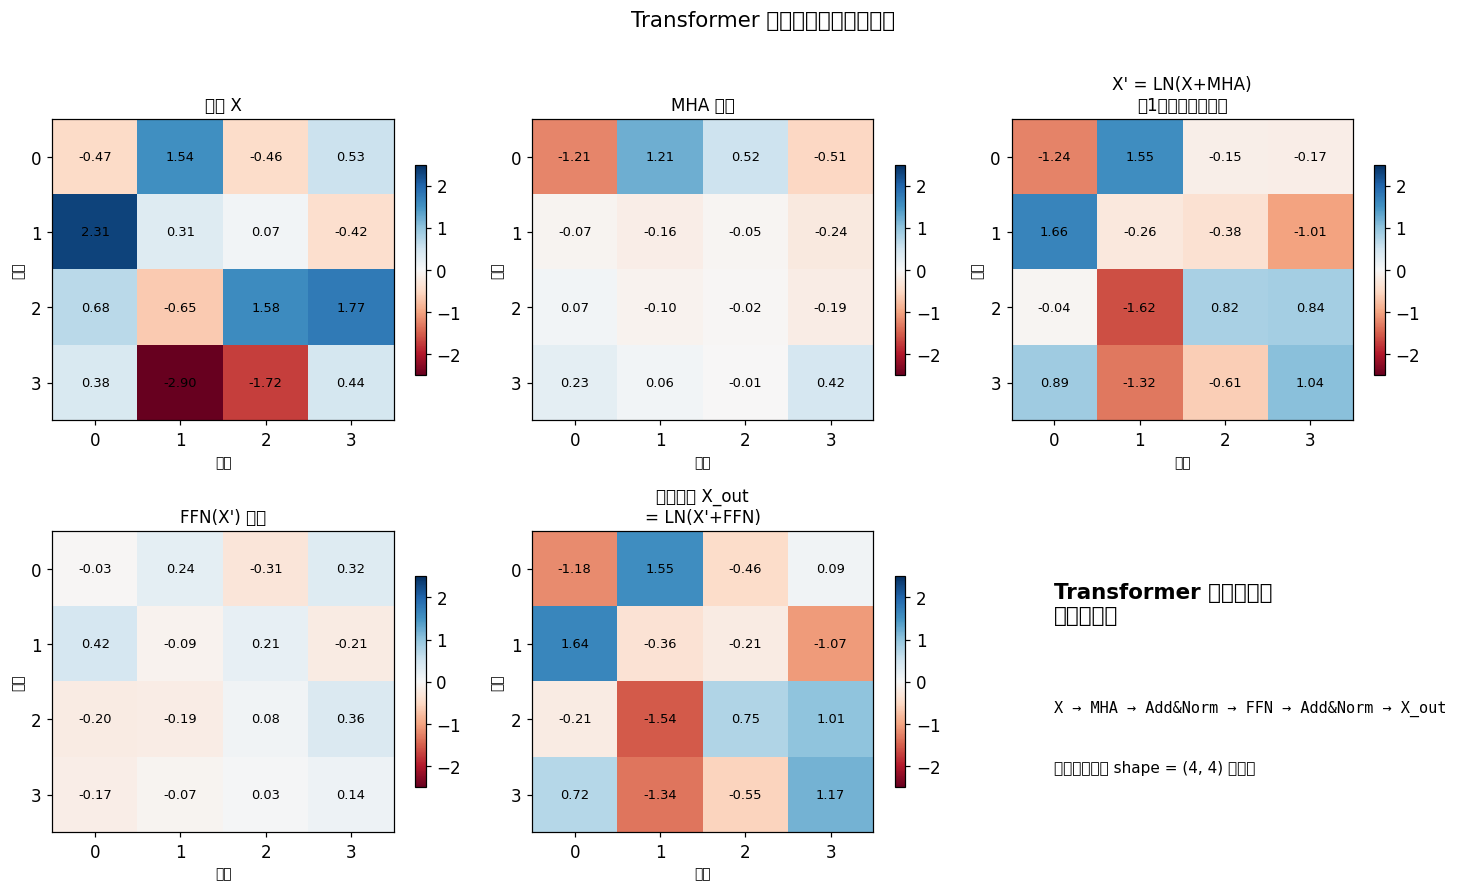

In [10]:
# ブロック全体の情報フロー可視化
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

stages = [X, mha_output, X_prime, ffn_output, X_out]
titles = ['入力 X', 'MHA 出力', 'X\' = LN(X+MHA)\n第1サブレイヤ出力',
          'FFN(X\') 出力', '最終出力 X_out\n= LN(X\'+FFN)', '']

for idx, (mat, title) in enumerate(zip(stages, titles)):
    ax = axes[idx]
    im = ax.imshow(mat, cmap='RdBu', aspect='auto', vmin=-2.5, vmax=2.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('次元', fontsize=9)
    ax.set_ylabel('位置', fontsize=9)
    ax.set_xticks(range(d_model))
    ax.set_yticks(range(seq_len))
    for i in range(seq_len):
        for j in range(d_model):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', fontsize=8.5)
    plt.colorbar(im, ax=ax, shrink=0.7)

axes[5].axis('off')
axes[5].text(0.1, 0.7, 'Transformer ブロックの\n情報フロー', fontsize=14, fontweight='bold')
axes[5].text(0.1, 0.4, 'X → MHA → Add&Norm → FFN → Add&Norm → X_out', fontsize=10, family='monospace')
axes[5].text(0.1, 0.2, f'全ステップで shape = ({seq_len}, {d_model}) を維持', fontsize=10)

plt.suptitle('Transformer ブロック内の情報変換', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('docs/nb03_block_flow.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4. Transformer ブロックのクラス化と N 層スタック

In [11]:
class MultiHeadAttention:
    def __init__(self, d_model, num_heads, seed=0):
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        rng = np.random.default_rng(seed)
        self.W_Qs = [rng.standard_normal((d_model, self.d_k))*0.5 for _ in range(num_heads)]
        self.W_Ks = [rng.standard_normal((d_model, self.d_k))*0.5 for _ in range(num_heads)]
        self.W_Vs = [rng.standard_normal((d_model, self.d_k))*0.5 for _ in range(num_heads)]
        self.W_O  = rng.standard_normal((d_model, d_model))*0.5

    def forward(self, X):
        heads = [sdpa(X@self.W_Qs[h], X@self.W_Ks[h], X@self.W_Vs[h]) for h in range(self.num_heads)]
        return np.concatenate(heads, axis=-1) @ self.W_O

class LayerNormLayer:
    def __init__(self, d_model, eps=1e-6):
        self.gamma = np.ones(d_model)
        self.beta  = np.zeros(d_model)
        self.eps   = eps

    def forward(self, x):
        mean = x.mean(axis=-1, keepdims=True)
        var  = x.var(axis=-1, keepdims=True)
        return self.gamma * (x - mean) / np.sqrt(var + self.eps) + self.beta

class FFN:
    def __init__(self, d_model, d_ff, seed=0):
        rng = np.random.default_rng(seed)
        self.W1 = rng.standard_normal((d_model, d_ff))*0.3
        self.b1 = np.zeros(d_ff)
        self.W2 = rng.standard_normal((d_ff, d_model))*0.3
        self.b2 = np.zeros(d_model)

    def forward(self, x):
        return gelu(x @ self.W1 + self.b1) @ self.W2 + self.b2

class TransformerBlock:
    def __init__(self, d_model, num_heads, d_ff, seed=0):
        self.mha = MultiHeadAttention(d_model, num_heads, seed=seed)
        self.ffn = FFN(d_model, d_ff, seed=seed+1)
        self.ln1 = LayerNormLayer(d_model)
        self.ln2 = LayerNormLayer(d_model)

    def forward(self, X):
        X = self.ln1.forward(X + self.mha.forward(X))   # 第1サブレイヤ
        X = self.ln2.forward(X + self.ffn.forward(X))   # 第2サブレイヤ
        return X

block = TransformerBlock(d_model=4, num_heads=2, d_ff=8, seed=42)
out   = block.forward(X)
print(f"TransformerBlock: 入力 {X.shape} → 出力 {out.shape}")
print(out)

TransformerBlock: 入力 (4, 4) → 出力 (4, 4)
[[-1.4808  1.2866 -0.1606  0.3549]
 [ 1.3931  0.4105 -0.5383 -1.2653]
 [-0.1428 -1.487   0.3456  1.2841]
 [ 0.9781 -1.153  -0.8341  1.009 ]]


In [12]:
# N 層スタック
n_layers = 3
blocks   = [TransformerBlock(d_model=4, num_heads=2, d_ff=8, seed=layer*10)
            for layer in range(n_layers)]

layer_outputs = [X.copy()]
current = X.copy()

print(f"入力 X: shape = {X.shape}")
for i, blk in enumerate(blocks):
    current = blk.forward(current)
    layer_outputs.append(current.copy())
    print(f"Layer {i+1} 後: shape = {current.shape}")
    print(current)
    print()

入力 X: shape = (4, 4)
Layer 1 後: shape = (4, 4)
[[-0.2682  1.6892 -0.8906 -0.5305]
 [ 1.4698  0.1243 -0.2709 -1.3232]
 [ 0.7808 -1.7176  0.4934  0.4434]
 [ 0.8233 -1.6307 -0.0068  0.8143]]

Layer 2 後: shape = (4, 4)
[[-0.7204  1.201   0.7402 -1.2209]
 [ 1.0392  0.1788  0.4269 -1.6449]
 [ 1.1509 -1.589   0.0536  0.3845]
 [ 1.2769 -1.1866 -0.737   0.6468]]

Layer 3 後: shape = (4, 4)
[[-1.2351  1.3308  0.5433 -0.6389]
 [-0.2956  1.0005  0.8015 -1.5064]
 [ 0.4296 -1.6952  0.3672  0.8983]
 [ 0.7335 -1.2566 -0.6728  1.1959]]



/tmp/ipykernel_2551/4186608586.py:18: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/4186608586.py:18: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/4186608586.py:18: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/4186608586.py:18: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/4186608586.py:18: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/4186608586.py:18: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/4186608586.py:18: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}

/tmp/ipykernel_2551/4186608586.py:19: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb03_layer_stack.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_2551/4186608586.py:19: UserWarning: Glyph 12391 (\N{HIRAGANA LETTER DE}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb03_layer_stack.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_2551/4186608586.py:19: UserWarning: Glyph 12393 (\N{HIRAGANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb03_layer_stack.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_2551/4186608586.py:19: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb03_layer_stack.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_2551/4186608586.py:19: UserWarning: Glyph 12424 (\N{HIRAGANA LETTER YO}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb03_layer_stack.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_25

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23652 (\N{CJK UNIFIED IDEOGRAPH-5C64}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12393 (\N{HIRAGANA LETTER DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12424 (\N{HIRAGANA LETTER YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12358 (\N{HIRAGANA LETTER U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, *

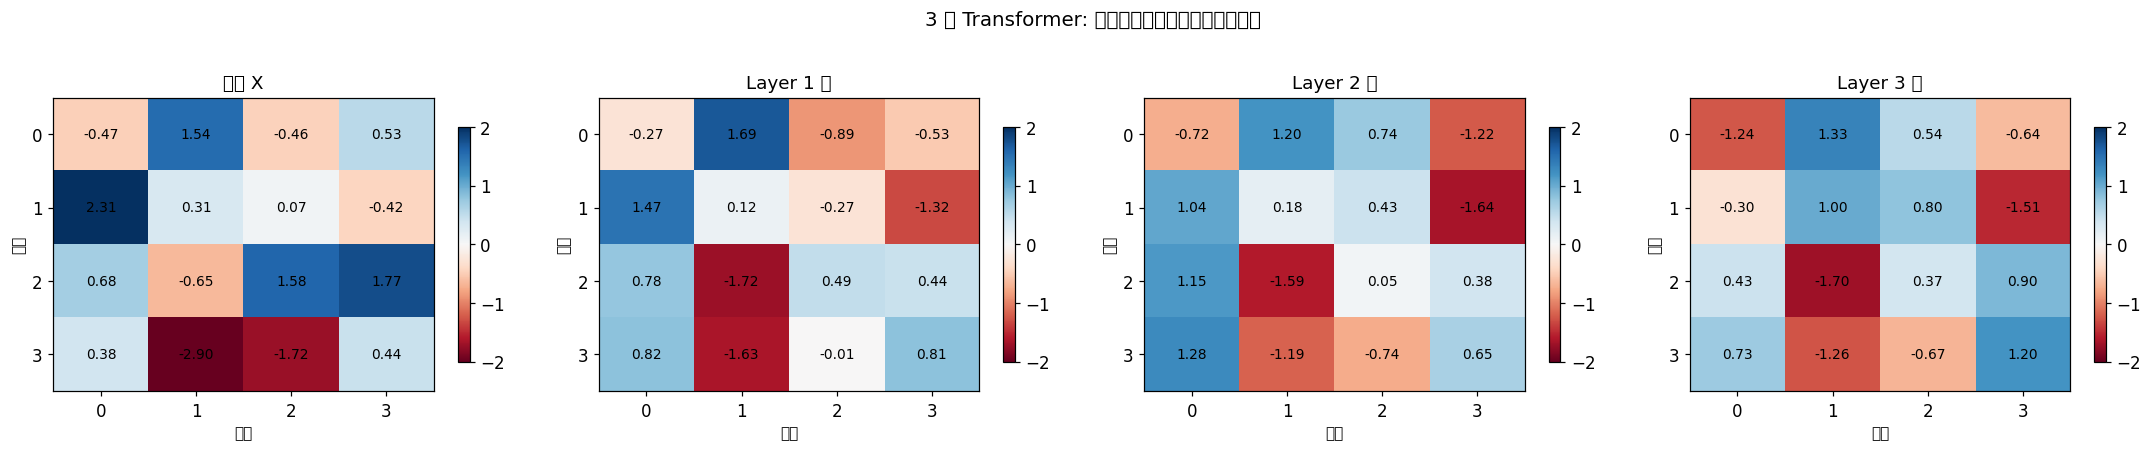

In [13]:
# 各層の出力変化を可視化
fig, axes = plt.subplots(1, n_layers+1, figsize=(5*(n_layers+1), 4))

for idx, (mat, ax) in enumerate(zip(layer_outputs, axes)):
    title = '入力 X' if idx == 0 else f'Layer {idx} 後'
    im = ax.imshow(mat, cmap='RdBu', aspect='auto', vmin=-2, vmax=2)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('次元', fontsize=10)
    ax.set_ylabel('位置', fontsize=10)
    ax.set_xticks(range(d_model))
    ax.set_yticks(range(seq_len))
    for i in range(seq_len):
        for j in range(d_model):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle(f'{n_layers} 層 Transformer: 各層でどのように変換されるか', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('docs/nb03_layer_stack.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. Language Model Head（LM ヘッド）

最終層の出力を語彙スコアに変換します：

$$\text{logits} = X_{\text{out}} W_{\text{lm}} \in \mathbb{R}^{L \times |V|}$$

`logits[i, j]` = 位置 $i$ の次トークンが語彙 $j$ である**生スコア**（正規化前）

In [14]:
np.random.seed(99)
W_lm = np.random.randn(d_model, vocab_size) * 0.3

logits = current @ W_lm   # (4, 8)
probs  = softmax(logits, axis=-1)

print(f"W_lm: shape = {W_lm.shape}  （{d_model} → {vocab_size}）")
print(f"logits: shape = {logits.shape}")
print(logits)
print()
print(f"probs (softmax 後): shape = {probs.shape}")
print(probs)
print()
print("各行の合計:", probs.sum(axis=-1).round(6))

W_lm: shape = (4, 8)  （4 → 8）
logits: shape = (4, 8)
[[ 0.2231 -1.7136 -0.0969 -0.1141 -0.0758  0.0729 -0.2013 -0.9195]
 [ 0.3597 -0.8238  0.1731  0.2503 -0.21   -0.2125  0.0678 -0.5728]
 [ 0.0357  1.2809 -0.1538 -0.1242 -0.0798  0.0375 -0.2891  0.8297]
 [-0.3009  1.2967 -0.0664 -0.1012  0.1483  0.0922  0.0311  0.7794]]

probs (softmax 後): shape = (4, 8)
[[0.1938 0.0279 0.1407 0.1383 0.1437 0.1668 0.1268 0.0618]
 [0.1886 0.0577 0.1565 0.169  0.1067 0.1064 0.1408 0.0742]
 [0.0911 0.3163 0.0753 0.0776 0.0811 0.0912 0.0658 0.2015]
 [0.0632 0.3124 0.0799 0.0772 0.0991 0.0937 0.0881 0.1863]]

各行の合計: [1. 1. 1. 1.]


/tmp/ipykernel_2551/2515922155.py:23: UserWarning: Glyph 35486 (\N{CJK UNIFIED IDEOGRAPH-8A9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/2515922155.py:23: UserWarning: Glyph 24409 (\N{CJK UNIFIED IDEOGRAPH-5F59}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/2515922155.py:23: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/2515922155.py:23: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/2515922155.py:23: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/2515922155.py:23: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2551/2515922155.py:23: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}

/tmp/ipykernel_2551/2515922155.py:24: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb03_lm_head.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_2551/2515922155.py:24: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb03_lm_head.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_2551/2515922155.py:24: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb03_lm_head.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_2551/2515922155.py:24: UserWarning: Glyph 27096 (\N{CJK UNIFIED IDEOGRAPH-69D8}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb03_lm_head.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_2551/2515922155.py:24: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb03_lm_head.png', dpi=120, bbox_inches='tight')
/tmp/

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

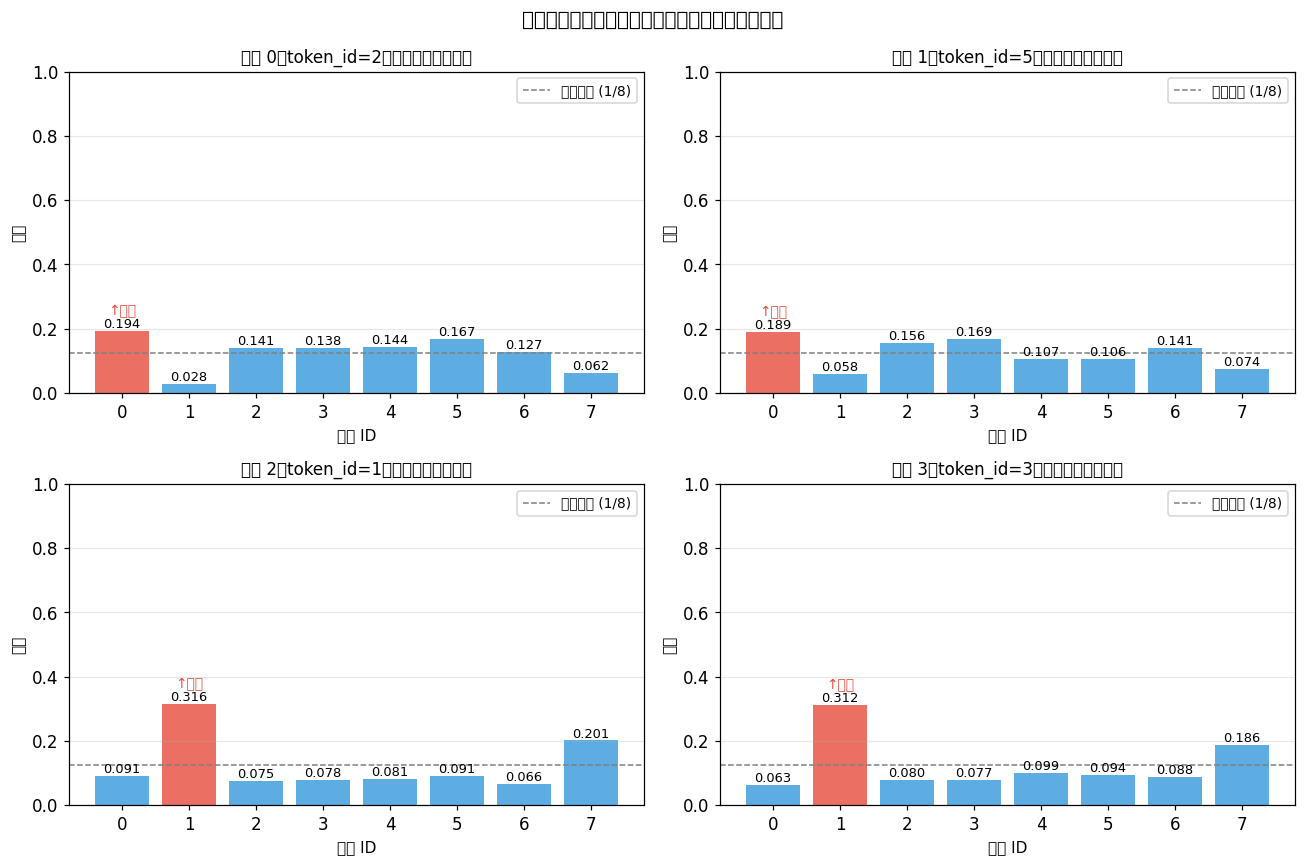

→ 未学習なのでほぼ一様分布。学習すれば正解トークンの確率が高くなる


In [15]:
# 各位置の予測分布を可視化
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for pos in range(seq_len):
    ax = axes[pos]
    p  = probs[pos]
    colors = ['#e74c3c' if p[j] == p.max() else '#3498db' for j in range(vocab_size)]
    bars = ax.bar(range(vocab_size), p, color=colors, alpha=0.8)
    ax.set_title(f'位置 {pos}（token_id={tokens[pos]}）の次トークン予測', fontsize=11)
    ax.set_xlabel('語彙 ID', fontsize=10)
    ax.set_ylabel('確率', fontsize=10)
    ax.set_xticks(range(vocab_size))
    ax.set_ylim(0, 1)
    ax.axhline(1/vocab_size, color='gray', ls='--', lw=1, label=f'一様分布 (1/{vocab_size})')
    for j, pj in enumerate(p):
        ax.text(j, pj + 0.01, f'{pj:.3f}', ha='center', fontsize=8.5)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.text(p.argmax(), p.max()+0.05, '↑最大', ha='center', color='#e74c3c', fontsize=9)

plt.suptitle('各位置での次トークン予測確率（未学習モデル）', fontsize=13)
plt.tight_layout()
plt.savefig('docs/nb03_lm_head.png', dpi=120, bbox_inches='tight')
plt.show()
print("→ 未学習なのでほぼ一様分布。学習すれば正解トークンの確率が高くなる")

---
## まとめ

### Transformer ブロックの全計算フロー

```
X (seq_len, d_model)                          shape = (4, 4)
 │
 ├──→ MultiHeadAttention(X) ─────────────┐
 │    ├── 各ヘッド: X@W_Q, X@W_K, X@W_V  │
 │    ├── sdpa: QK^T/√dk → softmax → @V  │
 │    └── Concat + @W_O                   │
 │                                        │
 └──────────────────────────── Add ────→ LayerNorm ─→ X' (4,4)
                                          │
 ┌─────────────────────────────────────── X'
 │                                        │
 ├──→ FFN(X')                             │
 │    ├── GELU(X'@W1+b1): (4,4)→(4,8)   │
 │    └── @W2+b2: (4,8)→(4,4)            │
 │                                        │
 └──────────────────────────── Add ────→ LayerNorm ─→ X_out (4,4)
                                          │
                                   @W_lm (4,4)×(4,8)
                                          │
                                   logits (4, vocab_size=8)
```

→ **次: `04_training_inference.ipynb`** では logits から損失を計算し学習と生成を行います。